Telescope Hex37-14.6m is not in known_telescopes.


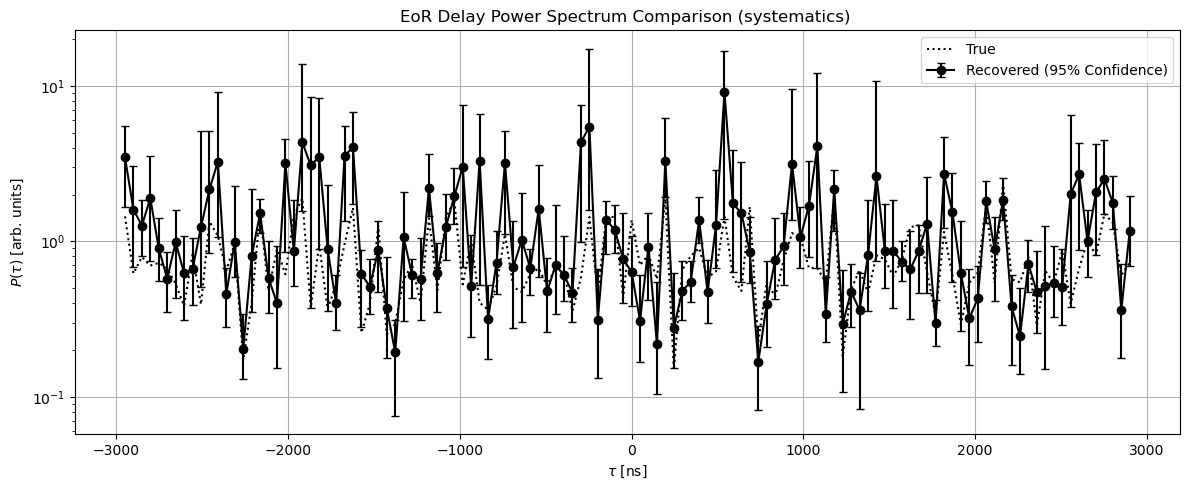

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from pyuvdata import UVData
from astropy import units
from jsonargparse import ArgumentParser
from pathlib import Path

from hydra_pspec.utils import form_pseudo_stokes_vis


# parser = ArgumentParser()
# parser.add_argument(
#     "--vis-eor",
#     type=str,
#     default="./vis-eor.uvh5",
#     help="Path to UVData compatible visibility file containing EoR "
#          "visibilities.  Defaults to './vis-eor.uvh5'."
# )
# parser.add_argument(
#     "--res-dir",
#     type=str,
#     default="./results-seed-7123689-Niter-1000/0-1/",
#     help="Path to a directory containing outputs from hydra-pspec.  Defaults "
#          "to './results-seed-7123689-Niter-1000/0-1/'."
# )
# parser.add_argument(
#     "--conf-interval",
#     type=int,
#     default=95,
#     help="Confidence interval for delay power spectrum posteriors."
# )
# parser.add_argument(
#     "--Nburn",
#     type=int,
#     default=0,
#     help="Number of samples to skip due to burn in.  Defaults to 0."
# )
# args = parser.parse_args()

vis_eor='vis-eor.uvh5'
res_dir='results-seed-7123689-Niter-100_v1/0-1/'
Nburn=0
conf_interval=95

# Load in EoR visibilities
uvd = UVData()
uvd.read(vis_eor)
uvd.conjugate_bls()
uvd = form_pseudo_stokes_vis(uvd)
# The test data only contains a single baseline (0, 1) and the pseudo-Stokes I
# visibilities after `form_pseudo_stokes_vis` are stored in the XX polarization
vis_eor = uvd.get_data((0, 1, "xx"))  # shape (Ntimes, Nfreqs)

# Get freuqency metadata
freqs = uvd.freq_array * units.Hz
if uvd.use_future_array_shapes:
    freqs = freqs[0]
df = freqs[1] - freqs[0]
Nfreqs = freqs.size

# Compute the delay power spectrum of the input EoR signal
axes = (1,)
ds_eor_true = np.fft.ifftshift(vis_eor, axes=axes)
ds_eor_true = np.fft.fftn(ds_eor_true, axes=axes)
ds_eor_true = np.fft.fftshift(ds_eor_true, axes=axes)
dps_eor_true = (np.abs(ds_eor_true)**2).mean(axis=0)
delays = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to("1/ns")))

# Load in results from hydra_pspec
dps_eor_hp = np.load(Path(res_dir) / "dps-eor.npy")
ln_post = np.load(Path(res_dir) / "ln-post.npy")
if Nburn > 0:
    dps_eor_hp = dps_eor_hp[Nburn:]
    ln_post = ln_post[Nburn:]
# Posterior-weighted mean delay power spectrum
dps_eor_hp_pwm = np.average(dps_eor_hp, weights=ln_post, axis=0)
# Confidence interval of delay power spectrum posteriors
percentile = conf_interval/2 + 50
dps_eor_hp_ubound = np.percentile(dps_eor_hp, percentile, axis=0)
dps_eor_hp_lbound = np.percentile(dps_eor_hp, 100-percentile, axis=0)
dps_eor_hp_err = np.vstack((
    dps_eor_hp_pwm - dps_eor_hp_lbound,
    dps_eor_hp_ubound - dps_eor_hp_pwm
))

# Plot the true and recovered delay power spectra
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(delays, dps_eor_true, "k:", label="True")
ax.errorbar(
    delays,
    dps_eor_hp_pwm,
    yerr=np.abs(dps_eor_hp_err),
    color="k",
    # ls="",
    marker="o",
    capsize=3,
    label=f"Recovered ({conf_interval}% Confidence)"
)
ax.legend(loc="upper right")
ax.set_xlabel(r"$\tau$ [ns]")
ax.set_ylabel(r"$P(\tau)$ [arb. units]")
ax.set_title("EoR Delay Power Spectrum Comparison (systematics) ")
ax.set_yscale("log")
ax.grid()
fig.tight_layout()
plt.show()


Data points minus the true model, with 68% error bars, and a linear y axis

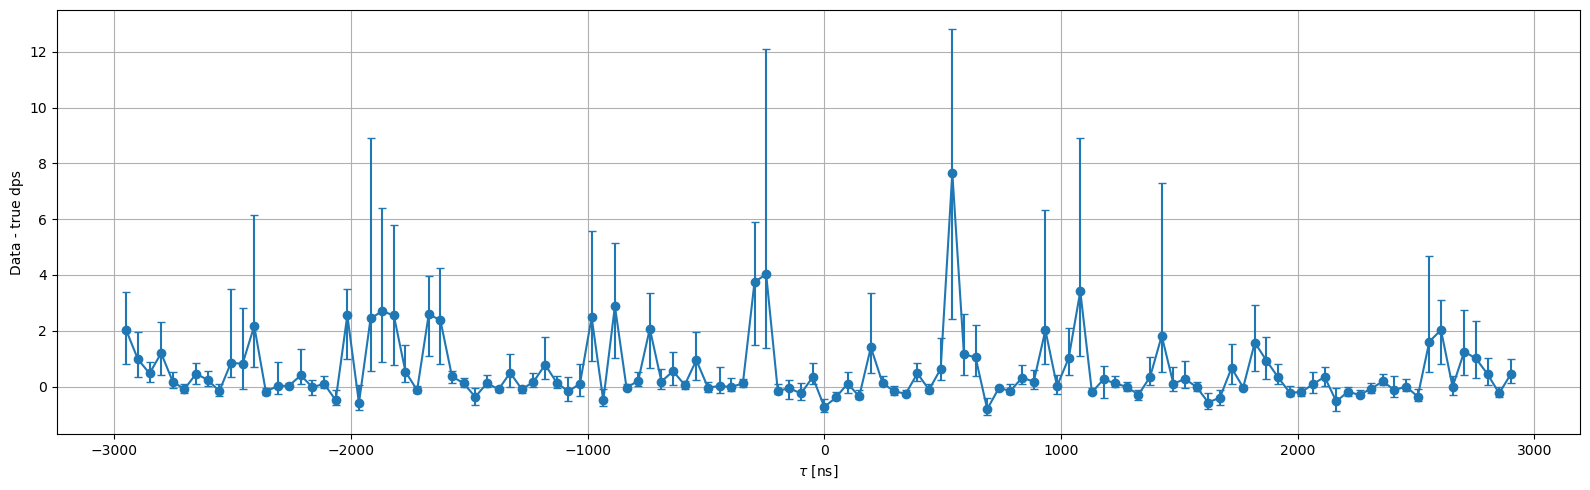

In [47]:
res=dps_eor_hp_pwm - dps_eor_true
fig, ax = plt.subplots(figsize=(16, 5))
ax.errorbar(delays,res, yerr=0.68*np.abs(dps_eor_hp_err),marker="o",
    capsize=3,)
ax.set_xlabel(r"$\tau$ [ns]")
ax.set_ylabel(r"Data - true dps")
ax.grid()
fig.tight_layout()

marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.


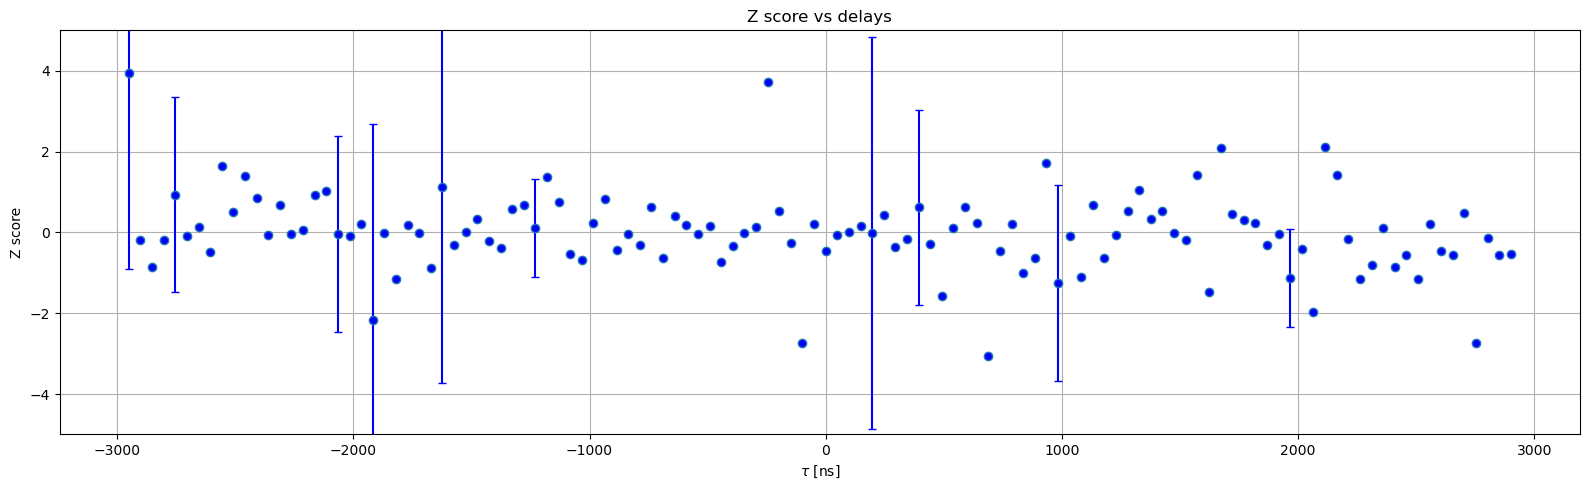

In [45]:
import scipy.stats as sci_st

z_sc=sci_st.zscore(res)
sig=np.std(dps_eor_hp_err)
yerr_z=dps_eor_hp_err/sig

fig, ax = plt.subplots(figsize=(16, 5))
ax.errorbar(delays,z_sc, yerr=np.abs(yerr_z),marker="o",fmt='o',markerfacecolor='blue',
    capsize=3,ecolor='blue')
ax.set_xlabel(r"$\tau$ [ns]")
ax.set_ylabel(r"Z score")
ax.set_title("Z score vs delays")
ax.set_ylim(-5,5)
ax.grid()
fig.tight_layout()

<ErrorbarContainer object of 3 artists>

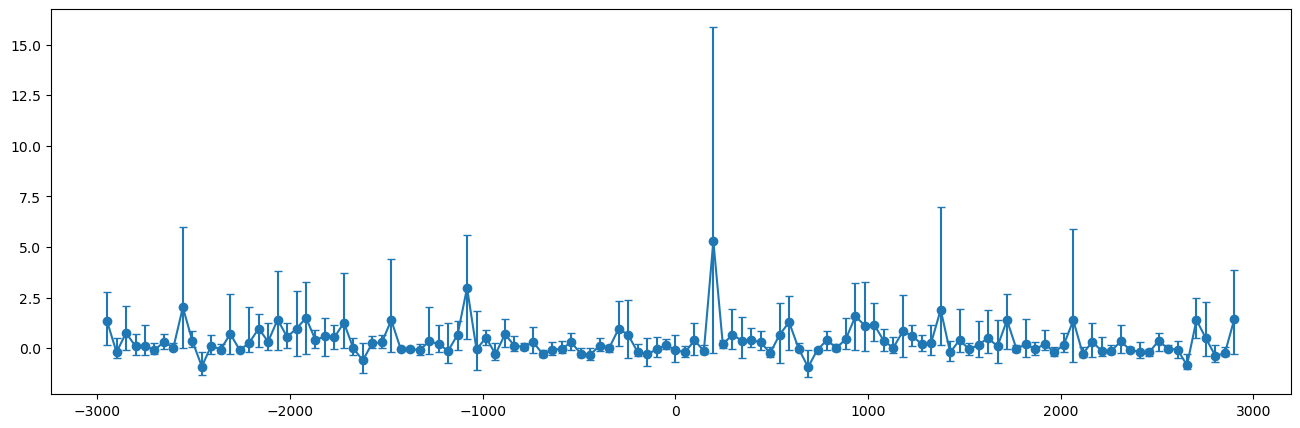

In [25]:
z_sc_2=res/np.std(dps_eor_hp_pwm)
fig, ax = plt.subplots(figsize=(16, 5))
ax.errorbar(delays,z_sc_2, yerr=yerr_z,marker="o",
    capsize=3,)

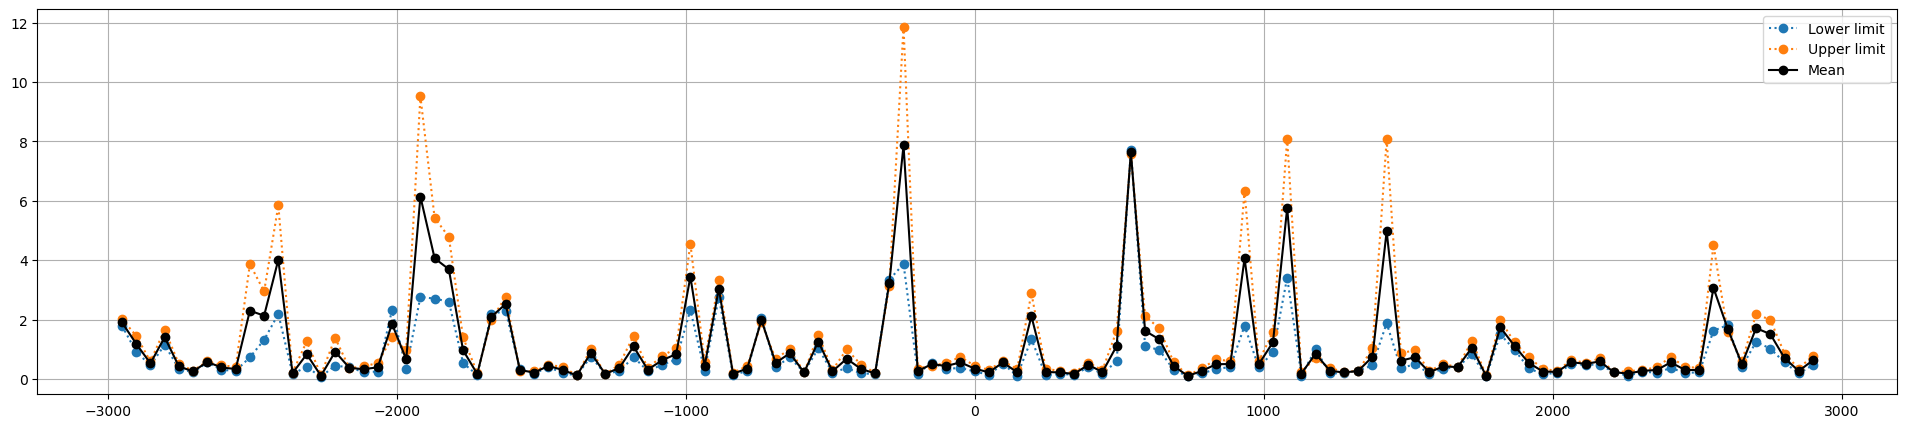

In [48]:
fig, ax = plt.subplots(figsize=(24, 5))
ax.plot(delays,dps_eor_hp_err[0,:],marker="o",label='Lower limit',ls='dotted')
ax.plot(delays,dps_eor_hp_err[1,:],marker="o",label='Upper limit',ls='dotted')
ax.plot(delays,np.mean(dps_eor_hp_err, axis=0),marker="o",label='Mean',c='k')
ax.grid()
ax.legend()

## Without systematics

Telescope Hex37-14.6m is not in known_telescopes.


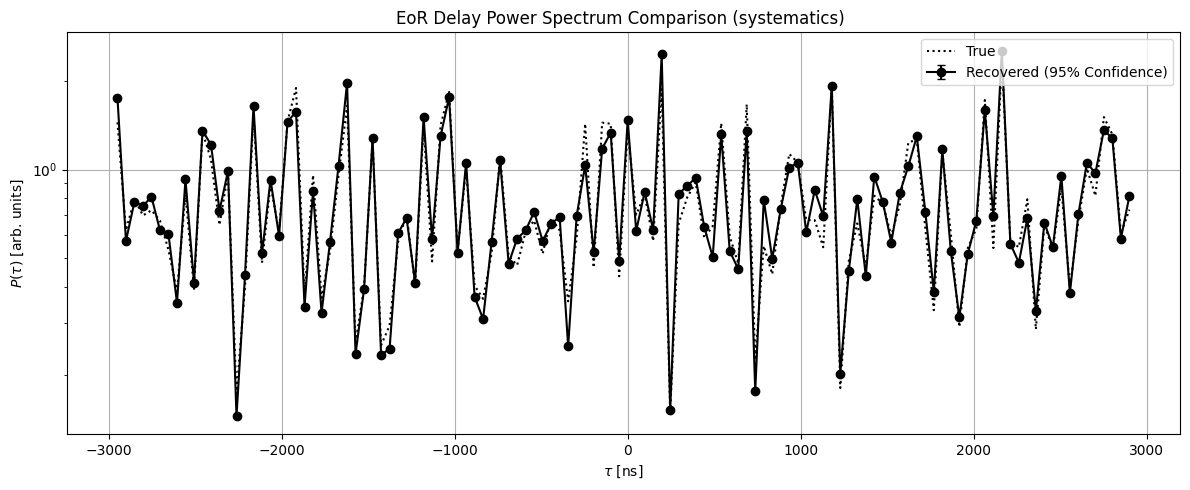

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pyuvdata import UVData
from astropy import units
from jsonargparse import ArgumentParser
from pathlib import Path

from hydra_pspec.utils import form_pseudo_stokes_vis

vis_eor='vis-eor.uvh5'
res_dir='/Users/user/Documents/Codes/hydra-pspec/results-seed-7123689-Niter-1000/0-1/'
Nburn=0
conf_interval=95

# Load in EoR visibilities
uvd = UVData()
uvd.read(vis_eor)
uvd.conjugate_bls()
uvd = form_pseudo_stokes_vis(uvd)
# The test data only contains a single baseline (0, 1) and the pseudo-Stokes I
# visibilities after `form_pseudo_stokes_vis` are stored in the XX polarization
vis_eor = uvd.get_data((0, 1, "xx"))  # shape (Ntimes, Nfreqs)

# Get freuqency metadata
freqs = uvd.freq_array * units.Hz
if uvd.use_future_array_shapes:
    freqs = freqs[0]
df = freqs[1] - freqs[0]
Nfreqs = freqs.size

# Compute the delay power spectrum of the input EoR signal
axes = (1,)
ds_eor_true = np.fft.ifftshift(vis_eor, axes=axes)
ds_eor_true = np.fft.fftn(ds_eor_true, axes=axes)
ds_eor_true = np.fft.fftshift(ds_eor_true, axes=axes)
dps_eor_true = (np.abs(ds_eor_true)**2).mean(axis=0)
delays = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to("1/ns")))

# Load in results from hydra_pspec
dps_eor_hp = np.load(Path(res_dir) / "dps-eor.npy")
ln_post = np.load(Path(res_dir) / "ln-post.npy")
if Nburn > 0:
    dps_eor_hp = dps_eor_hp[Nburn:]
    ln_post = ln_post[Nburn:]
# Posterior-weighted mean delay power spectrum
dps_eor_hp_pwm = np.average(dps_eor_hp, weights=ln_post, axis=0)
# Confidence interval of delay power spectrum posteriors
percentile = conf_interval/2 + 50
dps_eor_hp_ubound = np.percentile(dps_eor_hp, percentile, axis=0)
dps_eor_hp_lbound = np.percentile(dps_eor_hp, 100-percentile, axis=0)
dps_eor_hp_err = np.vstack((
    dps_eor_hp_pwm - dps_eor_hp_lbound,
    dps_eor_hp_ubound - dps_eor_hp_pwm
))

# Plot the true and recovered delay power spectra
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(delays, dps_eor_true, "k:", label="True")
ax.errorbar(
    delays,
    dps_eor_hp_pwm,
    yerr=np.abs(dps_eor_hp_err),
    color="k",
    # ls="",
    marker="o",
    capsize=3,
    label=f"Recovered ({conf_interval}% Confidence)"
)
ax.legend(loc="upper right")
ax.set_xlabel(r"$\tau$ [ns]")
ax.set_ylabel(r"$P(\tau)$ [arb. units]")
ax.set_title("EoR Delay Power Spectrum Comparison (systematics) ")
ax.set_yscale("log")
ax.grid()
fig.tight_layout()
plt.show()
